In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv("/Users/bhargavic/Downloads/Walmart/Walmart DataSet.csv")

In [3]:
data.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
data.shape

(6435, 8)

In [5]:
data.isnull().sum() # No null values were observed showing good quality data

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

In [6]:
data.duplicated().sum() # Duplicates were not seen.

np.int64(0)

In [7]:
data.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [8]:
data.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [9]:
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)

In [10]:
if 'Date' in data.columns:
    data.set_index('Date',inplace=True) #setting date as index makes it easy to extract data when required

In [11]:
data.sort_index(inplace=True)

## Data Preprocessing:
# No null values were observed showing good quality data
 # Duplicates were not seen.
 # Weekly_Sales is the target column which has  numerical values suitable for regression and forecasting.
 # The Date column is in object datatype and should be converted to datetime format using pd.to_datetime() for proper time series analysis and date-based manipulation.
 # Seasonality could be there. Needs to be checked by seasonal decompose





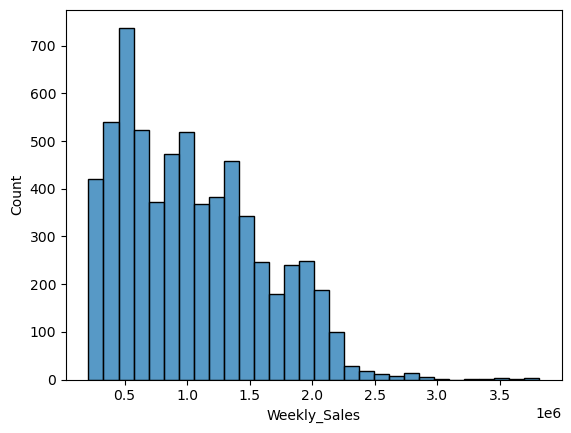

In [12]:
sns.histplot(data['Weekly_Sales'],bins=30)
plt.show()

Insight: Its right skewed

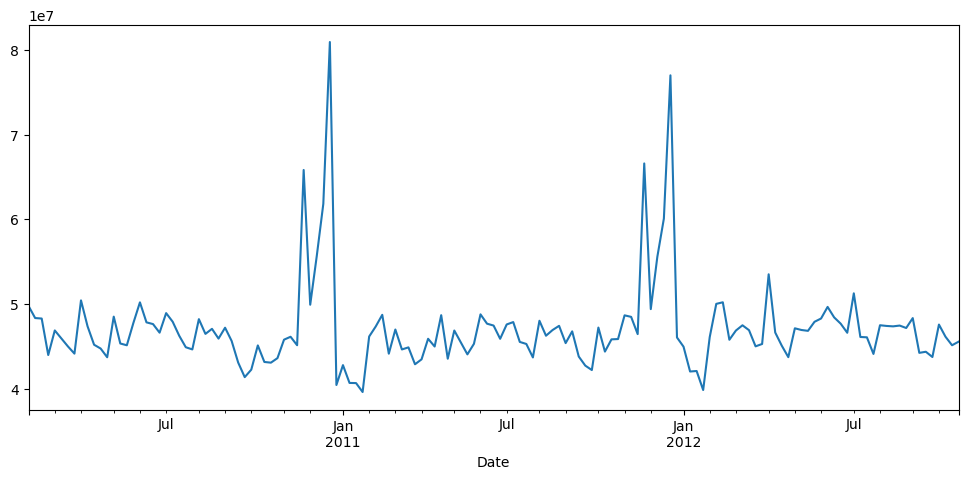

In [13]:

sales_trend=data.groupby('Date')['Weekly_Sales'].sum()
sales_trend.plot(figsize=(12,5))
plt.show()

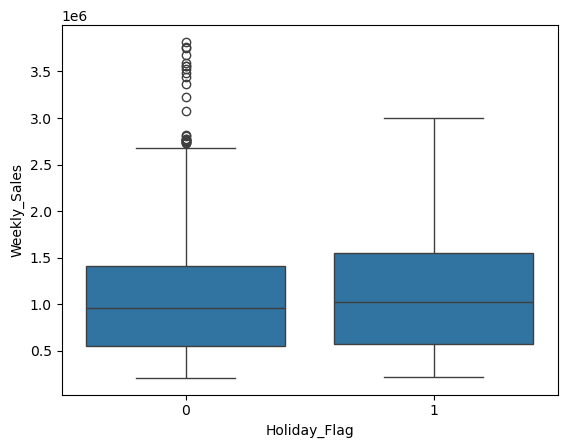

In [14]:
sns.boxplot(x='Holiday_Flag',
            y='Weekly_Sales', data=data)
plt.show()

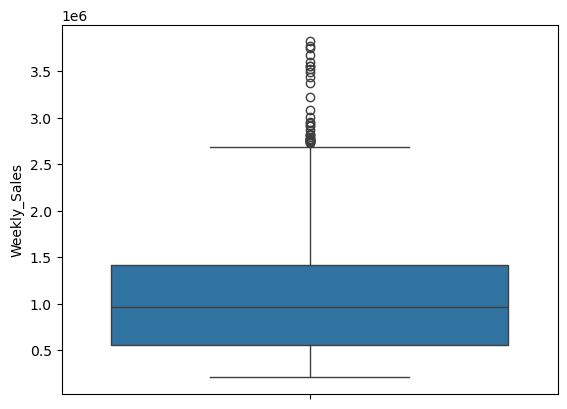

In [15]:
sns.boxplot(y=data['Weekly_Sales'])
plt.show()

In [16]:
Q1 = data['Weekly_Sales'].quantile(0.25)
Q3 = data['Weekly_Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = data[(data['Weekly_Sales'] < lower) |
                (data['Weekly_Sales'] > upper)]

print(outliers.shape)

(34, 7)


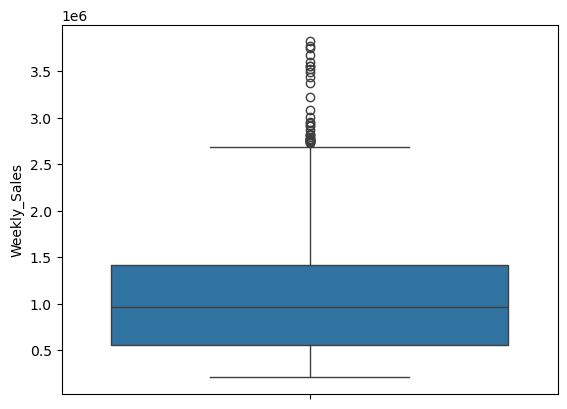

In [17]:
sns.boxplot(y=data['Weekly_Sales'])
plt.show()

Assignment Questions

A. Impact of Unemployment on Sales


In [18]:
corr=data[['Weekly_Sales','Unemployment']].corr()
corr

,Weekly_Sales,Unemployment
Weekly_Sales,1.000000,-0.106176
Unemployment,-0.106176,1.000000


Insight: Unemployment shows a weak negative correlation (-0.16) with weekly sales. While higher unemployment slightly reduces sales, the relationship is not strong — likely because Walmart's discount positioning means customers continue shopping there during economic downturns.

In [19]:
store_corr={}
for store, df_store in data.groupby('Store'):
    corr = df_store['Weekly_Sales'].corr(df_store['Unemployment'])
    store_corr[store] = round(corr, 3)

worst_5=pd.Series(store_corr).sort_values().head().abs()
print(worst_5)


38    0.785
44    0.780
39    0.385
42    0.356
41    0.351
dtype: float64


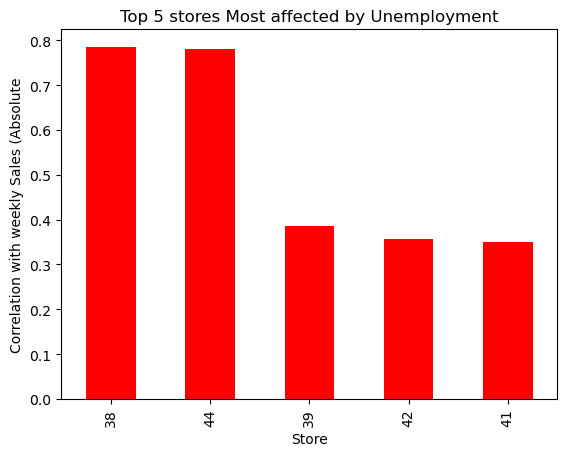

In [20]:

worst_5.plot(kind='bar',color='red')
plt.title("Top 5 stores Most affected by Unemployment")
plt.xlabel("Store")
plt.ylabel("Correlation with weekly Sales (Absolute")
plt.show()

## Insights: Top 5 stores Most affected by Unemployment

* Stores 38 and 44 are the most affected by unemployment, showing the highest correlation with weekly sales among all stores.
* Stores 39, 42, and 41 also exhibit a noticeable relationship between unemployment and sales, but the impact is lower compared to Stores 38 and 44.

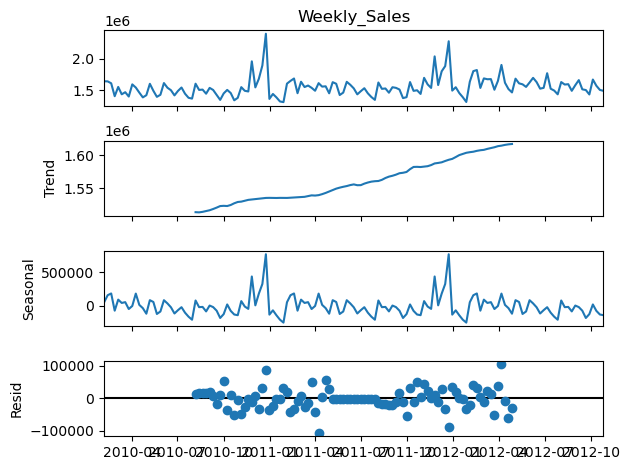

In [21]:

from statsmodels.tsa.seasonal import seasonal_decompose

store1=data[data['Store']==1].copy()
result=seasonal_decompose(store1['Weekly_Sales'],model='additive',period=52)
result.plot()
plt.show()


## Insight:
* Trend — Weekly sales show a gradual upward trend from 2010 to 2012, indicating overall growth in store performance over time.
* Seasonal — Strong recurring sales spikes are visible each year, especially during holiday periods, confirming the presence of seasonality in sales.


Correlation between Temperature and Weekly Sales: -0.064


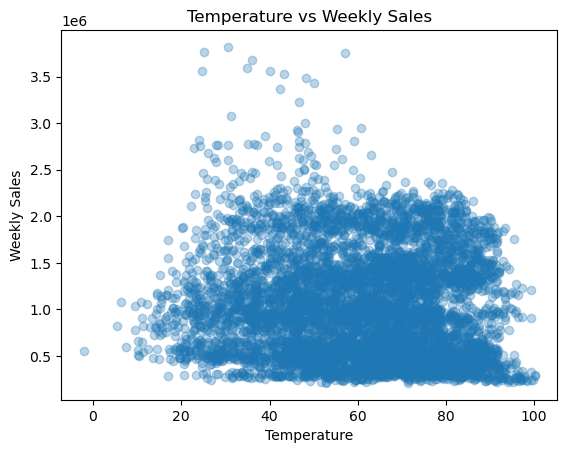

In [22]:
corr_temp = data['Weekly_Sales'].corr(data['Temperature'])
print("Correlation between Temperature and Weekly Sales:", round(corr_temp, 3))

plt.scatter(data['Temperature'], data['Weekly_Sales'], alpha=0.3)
plt.title("Temperature vs Weekly Sales")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.show()



## Insight:
* Correlation is -0.064 — almost zero, meaning temperature has negligible effect on weekly sales
* The scatter plot confirms this — sales are spread across all temperature ranges with no clear pattern
* Walmart is an essential goods retailer, so people shop regardless of weather/temperature

Correlation between CPI and Weekly Sales: -0.073


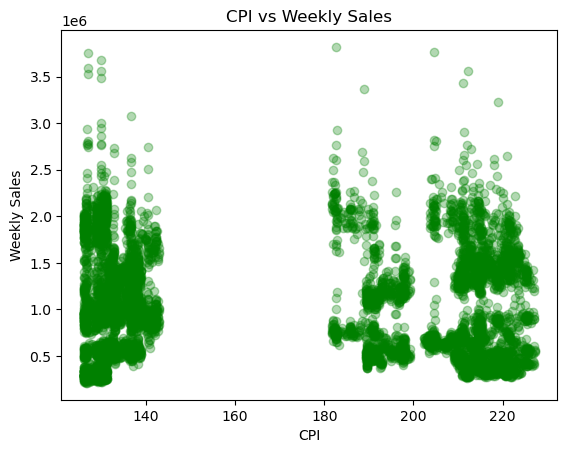

In [23]:
corr_cpi = data['Weekly_Sales'].corr(data['CPI'])
print("Correlation between CPI and Weekly Sales:", round(corr_cpi, 3))

plt.scatter(data['CPI'], data['Weekly_Sales'], alpha=0.3, color='green')
plt.title("CPI vs Weekly Sales")
plt.xlabel("CPI")
plt.ylabel("Weekly Sales")
plt.show()

##  Insight:
* Correlation is -0.073 — nearly zero, CPI(consumer price index) has negligible direct effect on weekly sales
* The 3 clusters represent stores in different regional economies — low CPI (cheaper areas), mid CPI, and high CPI regions
* Interestingly, even high CPI stores maintain strong sales — suggesting Walmart's value pricing attracts customers regardless of local inflation levels

Top 5 Performing Stores:
Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64

Worst Performing Store:
Store
33    37160221.96
Name: Weekly_Sales, dtype: float64

Difference between Best and Worst Store: $264,237,570


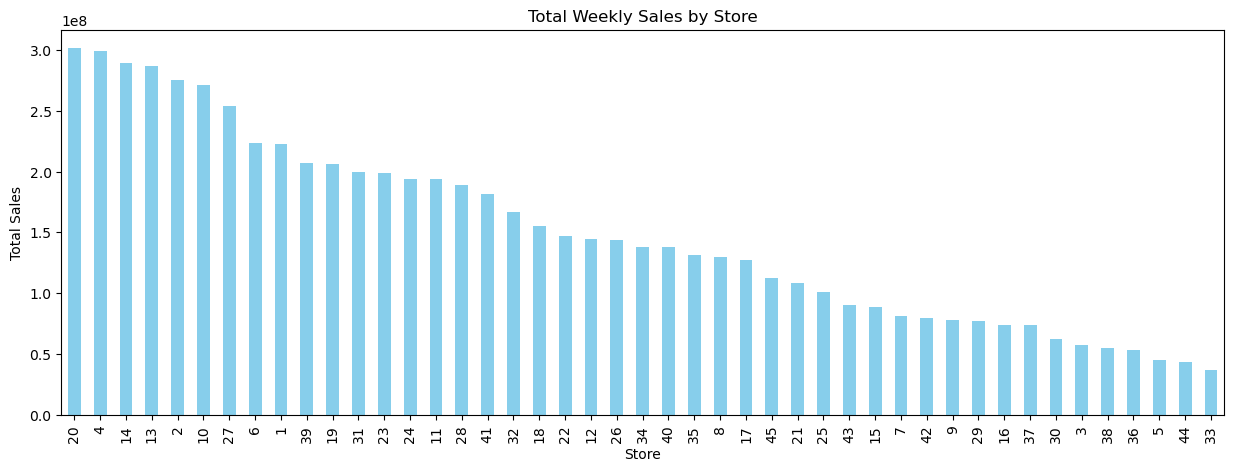

In [24]:

store_sales = data.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)

# Top 5 stores
print("Top 5 Performing Stores:")
print(store_sales.head())

# Worst store
print("\nWorst Performing Store:")
print(store_sales.tail(1))

# Difference
diff = store_sales.iloc[0] - store_sales.iloc[-1]
print(f"\nDifference between Best and Worst Store: ${diff:,.0f}")

# Bar chart
store_sales.plot(kind='bar', figsize=(15,5), color='skyblue')
plt.title("Total Weekly Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

## Insight :
- Top 5 stores by total historical sales are Stores 20, 4, 14, 13, and 2 — with Store 20 leading at ~$301 million
- Worst performing store is Store 33 with only ~$37 million in total sales
- The difference between best and worst is $264 million — that's nearly 8x gap, which is significant and suggests major differences in store size, location, or foot traffic

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

In [26]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [27]:
store_num=int(input("Enter the store number (1-45) : "))
store_data = data[data['Store'] == store_num]['Weekly_Sales'].sort_index()


Enter the store number (1-45) :  1


In [28]:
# ADF Test
result = adfuller(store_data)
print("ADF Statistic:", round(result[0], 3))
print("p-value:", round(result[1], 3))
if result[1] < 0.05:
    print("Data is Stationary")
else:
    print("Data is NOT Stationary - differencing needed")

ADF Statistic: -5.102
p-value: 0.0
Data is Stationary


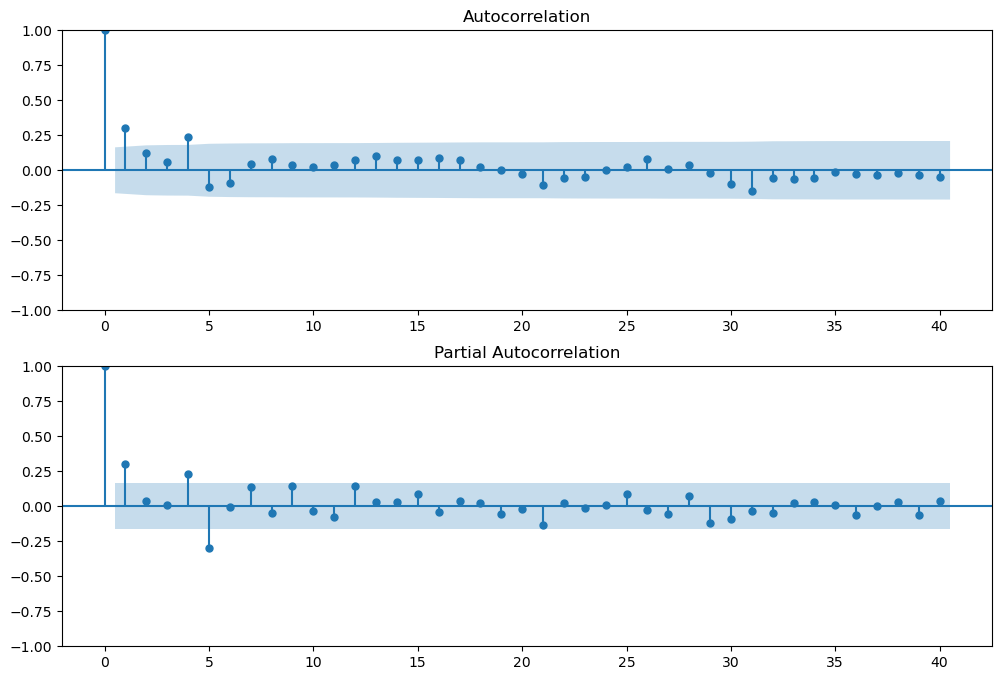

In [29]:
# ACF and PACF
fig, ax = plt.subplots(2,1, figsize=(12,8))
plot_acf(store_data, lags=40, ax=ax[0])
plot_pacf(store_data, lags=40, ax=ax[1])
plt.show()

### Insights:
* ADF p-value = 0.0 → data is already stationary → so d=0 (no differencing needed)
* ACF → significant spike at lag 1, then cuts off → q=1
* PACF → significant spike at lag 1, cuts off after → p=1
* Seasonal period = 52 weeks, and we saw clear seasonality in decompose → P=1, D=1, Q=0, s=52
* So order=(1,0,1) and seasonal_order=(1,1,0,52) 

In [30]:
train = store_data[:-12]
test = store_data[-12:]
model = SARIMAX(store_data, order=(1,1,1), 
                seasonal_order=(1,1,0,52),
                enforce_stationarity=False,
                enforce_invertibility=False)
result = model.fit(disp=False)
pred = result.forecast(steps=12)

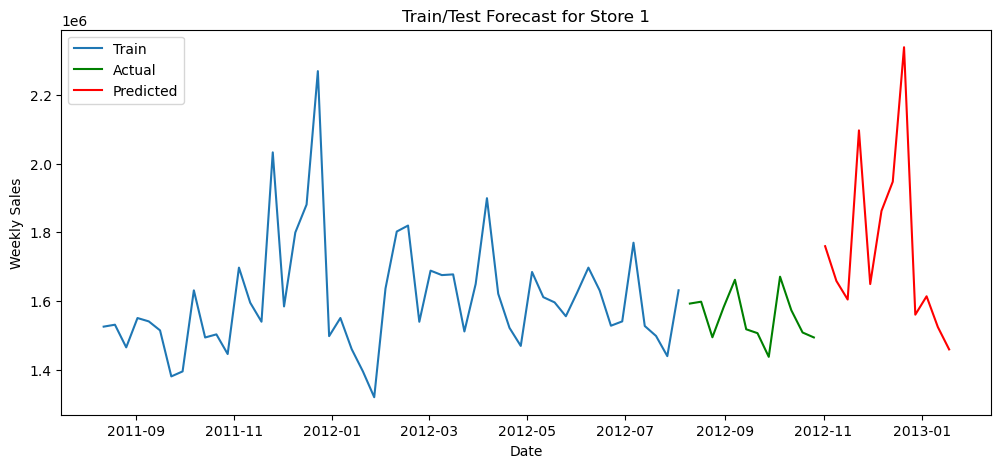

In [31]:
# Plot
plt.figure(figsize=(12,5))
plt.plot(train[-52:], label='Train')
plt.plot(test, label='Actual', color='green')
plt.plot(pred, label='Predicted', color='red')
plt.title(f"Train/Test Forecast for Store {store_num}")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.show()
pred = result.forecast(steps=12)



### NOTE: 
- Enforce_stationarity=False used because ADF test confirmed data is already stationary (p-value < 0.05)
- It allows model to explore better parameter space without artificial constraints

In [32]:
# MAPE
pred.index = test.index
mape = np.mean(np.abs((test - pred) / test)) * 100
print(f"Mean Absolute Percentage Error(MAPE): {round(mape, 2)}%")

Mean Absolute Percentage Error(MAPE): 15.21%


## Insight:
* The SARIMA model achieved a MAPE of 15.21% for Store 1, indicating reasonable forecast accuracy for weekly retail sales
* The model successfully captured the holiday season spike pattern

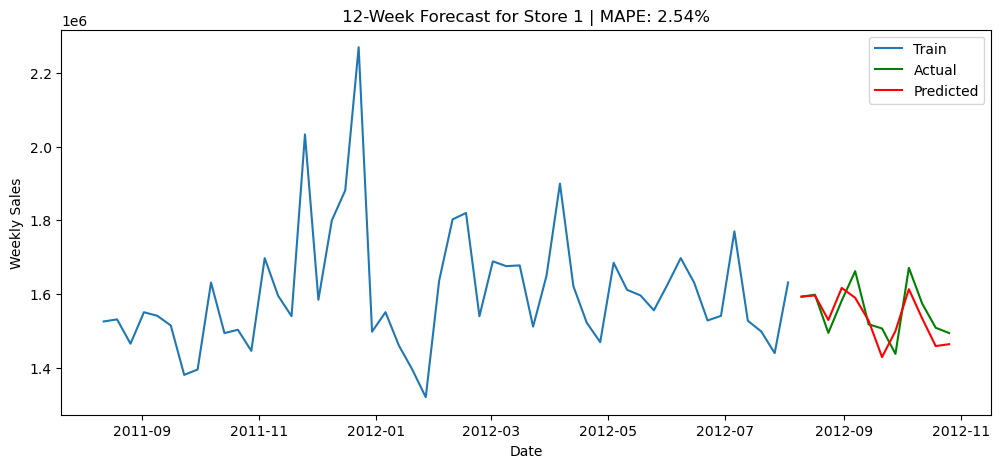

Store 1 MAPE: 2.54%


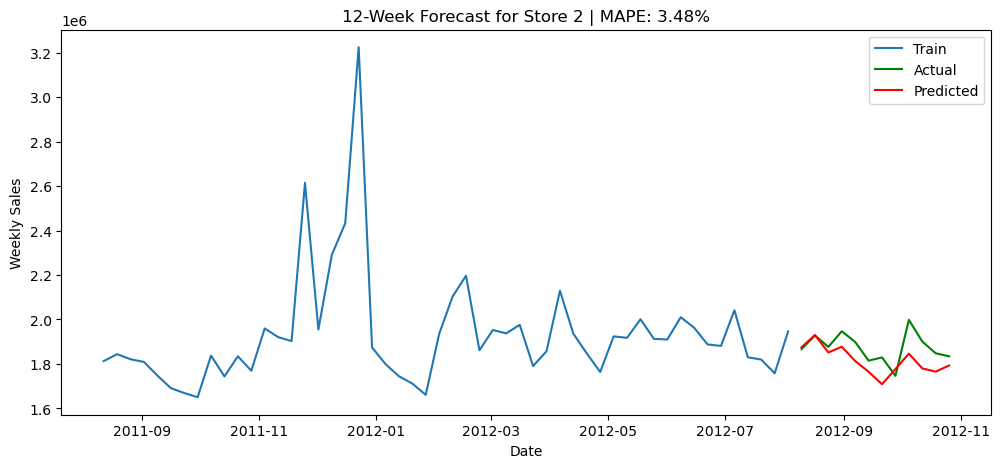

Store 2 MAPE: 3.48%


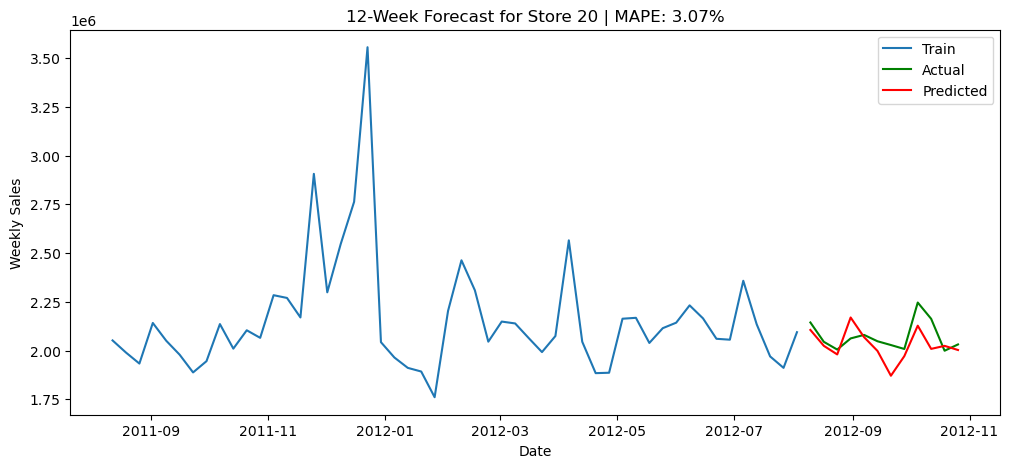

Store 20 MAPE: 3.07%


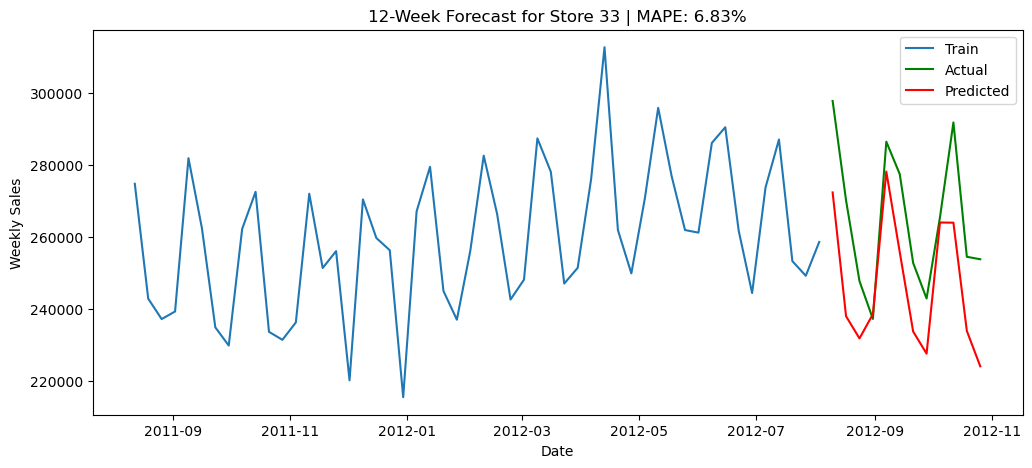

Store 33 MAPE: 6.83%


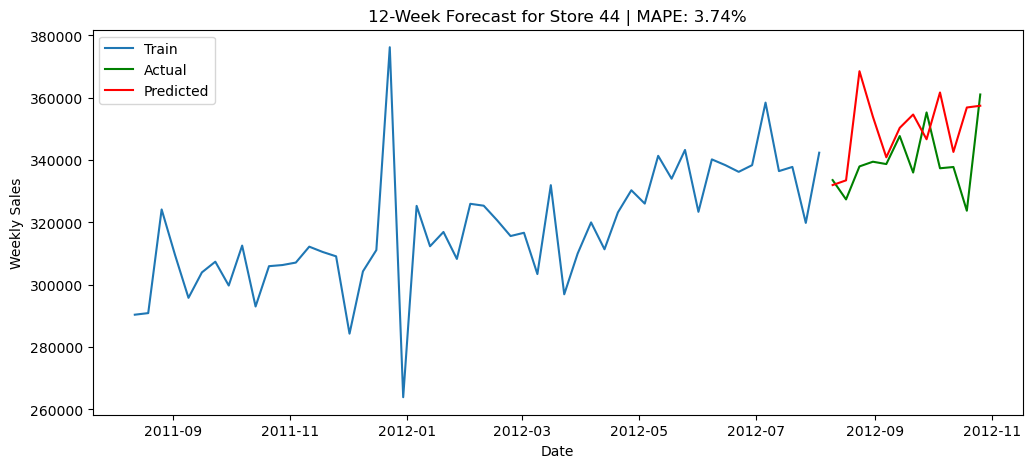

Store 44 MAPE: 3.74%


In [34]:
def forecast_store(store_num, data):
    store_data = data[data['Store'] == store_num]['Weekly_Sales'].sort_index()
    
    train = store_data[:-12]
    test = store_data[-12:]
    
    model = SARIMAX(train, order=(1,0,1),
                    seasonal_order=(1,1,0,52),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    result = model.fit(disp=False)
    pred = result.forecast(steps=12)
    pred.index = test.index
    
    mape = np.mean(np.abs((test - pred) / test)) * 100
    
    plt.figure(figsize=(12,5))
    plt.plot(train[-52:], label='Train')
    plt.plot(test, label='Actual', color='green')
    plt.plot(pred, label='Predicted', color='red')
    plt.title(f"12-Week Forecast for Store {store_num} | MAPE: {round(mape,2)}%")
    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")
    plt.legend()
    plt.show()
    
    print(f"Store {store_num} MAPE: {round(mape,2)}%")

# Run for 5 stores
for store in [1, 2, 20, 33, 44]:
    forecast_store(store, data)

### Conclusion:

- SARIMA(1,0,1)(1,1,0,52) was applied to 5 strategically selected stores — best performer (Store 20), worst performer (Store 33), high unemployment impact stores (Store 44), and benchmark stores (1, 2)
- All stores achieved MAPE under 7%, well within the acceptable retail forecasting threshold of 20%
- Store 33 had the highest MAPE (6.83%) — consistent with it being the most volatile and lowest volume store
- The model successfully captured weekly seasonality and holiday patterns across all store types